In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, opes_config, data, adam_hash, hash_configs
import json
from matplotlib.collections import LineCollection

In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
if data["dn"].lower() == "dayu19a":
    true_sample = np.load(base_path / "inputdata_260219A" / "true_sample.npy")
    bin_range = (1676, 1727)
    data_color = "red"
    data_name = r"$A_1$"
    ylim_max = 0.4
elif data["dn"].lower() == "dayu19b":
    true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
    bin_range = (1660, 1720)
    data_color = "orange"
    data_name = r"$A_2$"
    ylim_max = 0.15
if data["dn"].lower() == "dayu19c":
    true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
    bin_range = (1680, 1720)
    data_color = "yellow"
    data_name = r"$A_3$"
    ylim_max = 0.25
print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable
dayu19a
[ 4.57902257  8.36135651  5.11422104  8.94774521  3.77633915  2.62301897
  7.51392662  3.01083465  1.66440672  2.49766516  6.65021419  4.26488131
  2.82178752 13.72110374  5.00658969  4.22356615  9.98407875  5.05228054
 14.98356018  6.87770972  5.76046943  3.36974485  2.4027257   4.29853801
 13.58724645  4.44886226  5.27841171  8.50856018  3.61890868  1.97566217
  7.51449837  2.73906955 11.11440187  3.84391012  4.29268555  6.33982014
 12.47922743  5.8959843   6.12628828  1.71823439 23.98511197  1.41829163
 14.66210819 15.02047988  4.88741433 21.95400098 27.77322018  3.71905004
  3.71382915 42.30520838]
[1983.         1973.84195486 1957.11924185 1946.89079978 1928.99530935
 1921.44263104 1916.1965931  1901.16873986 1895.14707057 1891.81825712
 1886.8229268  1873.52249843 1864.99273582 1859.34916077 1831.90695329
 1821.8937739  1813.44664161 1793.47848412 1783.37392303 1753.

In [3]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [4]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 100000
# adam_hash_ee = hash_configs(adam_config_ee, data)

adam_dir = base_dir / f"output/{data["dn"]}/sd_{opes_config["hmcc"]["sd"]}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

np.random.seed(opes_config["hmcc"]["sd"])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (opes_config["hmcc"]["nch"], data["N"]))
# d18o_energies = np.load(adam_dir_ee / "adam_d18o_energies.npy")
# print(np.min(d18o_energies))
# sp_adams = np.load(adam_dir_ee / "adam_samples.npy")

opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
opes_config["df"] = 140 * (opes_config["bs"] - 1)
print(opes_config["df"][-1])
opes_config["dfn"] = np.exp(-opes_config["df"])*opes_config["dfd"]

opes_hash = hash_configs(opes_config, data)
output_dir = adam_dir / f"{opes_hash}"

hmc_config = opes_config["hmcc"]

-133.0


In [5]:
# base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 100000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/sd_{opes_config["hmcc"]["sd"]}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# np.random.seed(opes_config["hmcc"]["sd"])
# sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (opes_config["hmcc"]["nch"], data["N"]))
# d18o_energies = np.load(adam_dir_ee / "adam_d18o_energies.npy")
# print(np.min(d18o_energies))
# sp_adams = np.load(adam_dir_ee / "adam_samples.npy")

# opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
# opes_config["df"] = 140 * (opes_config["bs"] - 1)
# print(opes_config["df"][-1])
# opes_config["dfn"] = np.exp(-opes_config["df"])*opes_config["dfd"]

# opes_hash = hash_configs(opes_config, data)
# output_dir = adam_dir / f"{opes_hash}"

# hmc_config = opes_config["hmcc"]

In [6]:
print(output_dir)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable\output\dayu19A\sd_10\b67d17f36a


In [7]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

In [8]:

# cumulative_sums = np.cumsum(sp_adams, axis=1) * data["dc"]
# zeros = np.zeros((*sp_adams.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(sp_adams)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# # plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
# plt.show()

In [9]:

# cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
# zeros = np.zeros((*sp.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(sp)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
# plt.show()

In [10]:
# base_dir = Path.cwd()

# df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")
# print(df[:, -1, :])

In [11]:
# fig, ax = plt.subplots()
# ind = -1
# chain = 0
# x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
# sample_delta_F = np.squeeze(df[chain, :, ind])
# ax.plot(x[:100000], sample_delta_F[:100000], '*-', color = temp_colors[1])
# plt.legend()
# plt.xlabel(f"sample")
# plt.ylabel(r"$\Delta F$")
# plt.savefig(f"{output_dir}/df_{ind}.jpg")
# plt.show()


In [12]:
# import matplotlib as mpl
# fig, ax = plt.subplots()

# norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
# cmap = plt.cm.viridis

# for k in range(opes_config["nt"]):
#     sample_delta_F = np.squeeze(df[chain, :, k])
#     ax.plot(x[:100000], -sample_delta_F[:100000], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

# plt.xlabel(f"q")
# plt.ylabel(r"$g_{s, q}$")

# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label(r"$\beta_s$")
# ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
# cbar.set_ticks(ticks)
# cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
# cbar.ax.yaxis.set_minor_locator(
#     plt.FixedLocator(opes_config["bs"])
# )

# plt.tight_layout()
# plt.savefig(f"{output_dir}/gs.jpg")
# plt.show()


In [13]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(opes_config["bs"], df[i, -1, :], marker = '*', color = "green")

# plt.savefig(f"{output_dir}/df_to_beta.jpg")
# plt.show()

# # other_df = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/python/src/age_depth_models/age_depth_model_OPES_normal_clean_d18o_stable/output/{data['dn']}/sd_{42}/fb797e5f6c/df.npy")
# other_opes_config = opes_config
# other_opes_config["hmcc"]["sd"] = 10
# other_opes_hash = hash_configs(other_opes_config, data)
# other_df = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/python/src/age_depth_models/age_depth_model_OPES_normal_clean_d18o_stable/output/{data['dn']}/sd_{10}/{other_opes_hash}/df.npy")

# plt.figure()
# plt.plot(opes_config["bs"], df[0, -1, :] - other_df[0, -1, :], marker = '*', color = "green")

# plt.savefig(f"{output_dir}/df_to_beta_compare.jpg")
# plt.show()

In [14]:
# del df, other_df
# gc.collect()

In [15]:
cutout = 10000
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [16]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[ 98354.37573333 108769.94882906 111263.95915073 102595.98967152
  97127.75031734 106974.34832789 107737.7255903  102429.23149296
 110441.63496661 104951.61160433 104768.35109383 105537.57068343
  97127.08382906 101203.53694621 100838.06400186 105946.79409815
 101136.97913091 103411.06227542 113024.80443765  98948.46759648]


In [17]:
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     ax.hist(energy_values[i, cutout:], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
# plt.legend()
# plt.savefig(f"{output_dir}/energy_hist.jpg")
# plt.show()   

In [18]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), bias_values[i, cutout:100000], color = colors[i], alpha = 0.5, label = f"Chain {i}")
#     plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), energy_values[i, cutout:100000], color = colors[i], alpha = 0.5)
# plt.xlabel("q")
# plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
# plt.legend()
# plt.savefig(f"{output_dir}/energy_and_bias.jpg")
# plt.show()

In [19]:
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

In [20]:
# plt.figure()
# for i in range(hmc_config["nch"]):
#     plt.plot(np.linspace(cutout, len(bias_values[0, :]), len(bias_values[i, cutout:])), bias_values[i, cutout:], color = colors[i])
#     plt.plot(np.linspace(cutout, len(bias_values[0, :]), len(bias_values[i, cutout:])), d18o_energy_values[i,cutout:], color = colors[i])
# plt.savefig(f"{output_dir}/d18o_energy_and_bias.jpg")
# plt.show()
# print(np.min(d18o_energy_values))

In [21]:
# print("Reweighting energies for each temp\n")
# temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

# # Compute betas

# # Initial beta
# energy_samples = []
# all_weights = []

# for j in range(opes_config["nt"]):
#     temp_energy_samples = []
#     weights = np.exp(-(opes_config["bs"][j] - 1) * d18o_energy_values + bias_values)
#     for i in range(hmc_config["nch"]):
#             weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
#             indices = np.random.choice(
#                 np.arange(cutout, len(weights_i) + cutout),
#                 size=int(len(weights_i)),
#                 replace=True,
#                 p=weights_i,
#             )
#             temp_energy_samples.append(energy_values[i, indices])

#     print(f"Temp {j} done resampling")
#     all_weights.append(weights)
#     energy_samples.append(temp_energy_samples)

# del indices, temp_energy_samples, d18o_energy_values
# gc.collect()
# energy_samples = np.array(energy_samples)

In [22]:
# all_weights = np.array(all_weights)
# n_eff = np.sum(all_weights, axis = 2)**2 / np.sum(all_weights**2, axis = 2)
# plt.figure()
# plt.plot(opes_config["bs"], n_eff / hmc_config["ns"])
# plt.show()

# del all_weights, n_eff
# gc.collect()


In [23]:
# limit_grid = np.linspace(80, 190, 100)
# bin_grid = limit_grid[:-1]
# mean_energies = np.zeros((hmc_config["nch"], opes_config["nt"]))
# energy_stds = np.zeros((hmc_config["nch"], opes_config["nt"]))

# for k in range(hmc_config["nch"]):
#     fig, ax = plt.subplots(figsize=(6, 4))
#     for j in range(opes_config["nt"]):
#         ax.hist(energy_samples[j, k], bins = 100, color = temp_colors[j], label = f"temp {opes_config["bs"][j]}", alpha = 0.5, density = True)
#         mean_energies[k,j]  = np.mean(energy_samples[j, k])
#         energy_stds[k,j]  = np.std(energy_samples[j, k])
    
#     plt.savefig(f"{output_dir}/temp_pic_chain_{k}.jpg")
#     plt.show()

# del energy_samples, mean_energies, energy_stds, energy_values
# gc.collect()

In [24]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [25]:
# min_energies = [np.min(energy_values, axis = 1)[i] for i in range(hmc_config["nch"])]
# min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(hmc_config["nch"])]
# closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(hmc_config["nch"])]
# print(min_energies)

In [26]:
# chain = 0
# fig, ax = plt.subplots(figsize=(6, 4))
# # plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
# ax.plot(data["cs"], true_ages, color = data_color, linewidth=1, alpha = 1, label = data_name + "(d)")
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
# plt.show()



In [27]:
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
# ax.errorbar(
#     data["d18ota"], 
#     data["d18o"], 
#     yerr=data["d18os"],       # The error values (can be a constant or array)
#     color=data_color, 
#     ecolor = "grey",
#     fmt = ".k", 
#     markersize=7,                # Makes the stars smaller (default is 6)
#     linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     elinewidth=2,              # Optional: makes the error bar lines thinner
#     label=r"$\delta^{18}$O data for $A_1(d)$"
# )

# # ax.scatter(
# #     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
# #     data["d18o"], 
# #     # yerr=data["d18os"],       # The error values (can be a constant or array)
# #     color="black", 
# #     marker="*", 
# #     s=10,                # Makes the stars smaller (default is 6)
# #     # linestyle="None",            # Ensures no lines connect the points
# #     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
# #     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
# #     label=r"Data regenerated from $A_{close}(d)$"
# # )

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"$\delta^{18}$O data for $A_{max}(d)$"
# )
# # ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# # ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
# plt.xlim((1650, 1750))
# plt.ylabel("$\\delta^{18}$O [‰]")
# plt.xlabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/data_compare.jpg")
# plt.show()


In [28]:
# Print R_hat and N_eff using arviz
# idata = az.convert_to_inference_data(samples[:, :, :])
# summary = az.summary(idata, round_to=2)
# print(summary)
# del summary, idata
# gc.collect()
# ess_array = np.array([az.ess(samples[0:1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
# print(ess_array)

In [29]:
# print(np.min(ess_array))
# min_ess = np.min(ess_array)/hmc_config["nch"]
# print(min_ess)

In [30]:
# resampled_samples = []
weights = np.exp(bias_values)
# local_indices_list = []
# for i in range(hmc_config["nch"]):
#     weights_i = weights[i, :] / sum(weights[i, :])

#     indices = np.random.choice(
#         np.arange(0, len(weights_i)),
#         size=15000,
#         replace=True,
#         p=weights_i,
#     )
#     resampled_samples.append(samples[i, indices, :])
#     print(f"Chain {i} done resampling")

# resampled_samples = np.array(resampled_samples)

In [31]:
# resampled_samples = flat_samples[indices, :]

In [32]:
# short_samples = samples[:, cutout::10, :]
# del samples
# gc.collect()
# short_resampled_samples = resampled_samples[:, :, :]
# del resampled_samples
# gc.collect()

In [33]:
# # index = 25
# # interesting_depth = index * data["dc"]
# # CV_values = data["th"] - data["dc"] * np.sum(short_samples[:, :, :index], axis = 2)
# # fig, ax = plt.subplots(figsize=(6, 4))
# # # for i in range(hmc_config["nch"]):
# # ax.hist(CV_values[0, :], bins = 100, color = "grey", label = f"chain {i}", alpha = 0.5, density = True)
# # plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}_chain0.jpg")
# # plt.show()
# index = 25
# interesting_depth = index * data["dc"]
# CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[-1][:, :index], axis = 1)
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
# ax.set_xlabel("Year CE")
# ax.set_ylabel("Marginal Density")
# ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
# plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
# plt.show()

# # fig, ax = plt.subplots(figsize=(6, 4))
# # for i in range(hmc_config["nch"]):
# #     ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
# # plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
# # plt.show()

In [34]:
chain = 0
index = 25
interesting_depth = index * data["dc"]
dt = 1
print(np.shape(weights))

(20, 990000)


In [35]:
# ### Jackknife
block_size = int(len(samples[chain, :, 0])/5000)
# fig, ax = plt.subplots(figsize=(6, 4))
# hists = []
# bins = np.arange(bin_range[0], bin_range[1] + dt, dt)
# bin_centers = bins[1:] - dt / 2
# print(np.shape(data["th"] - data["dc"] * np.sum(samples[chain, :, :index], axis = 1)))
# print(np.shape(weights[chain]))
# print(block_size)
# full_CV_values = np.histogram(data["th"] - data["dc"] * np.sum(samples[chain, :, :index], axis = 1), density = True, bins = bins, weights = weights[chain])
# bin_edges = full_CV_values[1]
# print(bin_edges)
# print(np.arange(i*block_size, (i+1)*block_size))
# print(int(len(samples[0, :, 0])/block_size))
# for i in range(int(len(samples[0, :, 0])/block_size)):
#     delete_block = np.arange(i*block_size, (i+1)*block_size)
#     CV_values = data["th"] - data["dc"] * np.sum(np.delete(samples[chain], delete_block, axis=0)[:, :index], axis = 1)
#     hists.append(np.histogram(CV_values, density = True, bins = bins, weights = np.delete(weights[chain], delete_block, axis=0))[0])
#     if (i%100 ==0):
#         print(i * block_size/len(samples[chain, :, 0]))


In [36]:
# # ax.hist(CV_values, bins = bins, color = "grey", alpha = 0.5, density = True)
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.hist(data["th"] - data["dc"] * np.sum(samples[chain, :, :index], axis = 1), density = True, bins = bins, weights = weights[chain], color = "grey")
# ax.set_xlabel("Year CE")
# ax.set_ylabel("Marginal Density")
# ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
# plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}_chain_{chain}_opes_{data["dn"]}.jpg")
# plt.show()

In [37]:
# # print(hists)
# n = len(samples[chain])
# # print(np.shape(full_CV_values[0]))
# # print(np.shape(np.array(hists)))
# variance  = (n-1) * np.sum((hists - full_CV_values[0][None, :])**2, axis = 0) / n
# print(variance)

In [38]:
# # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# fig, ax = plt.subplots(figsize=(6, 4))

# # jackknife_array = np.array([n*full_CV_values[0] - (n-1) * hists[i] for i in range(len(hists))])
# # print(np.shape(jackknife_array))
# # jackknife_est = np.mean(jackknife_array, axis = 0)
# # print(jackknife_est - full_CV_values[0])
# # print(full_CV_values[0])

# # 3. Plot
# ax.errorbar(bin_centers, full_CV_values[0], yerr=2*np.sqrt(variance), fmt='none', color = "grey", capsize=3, label = r"2$\sigma$ errorbar")
# ax.bar(bin_centers, full_CV_values[0], width=np.diff(bin_edges), alpha=0.3, color='gray', align='center')
# ax.set_ylim(0, ylim_max)
# ax.set_xlabel("Year CE")
# ax.set_ylabel("Marginal Density")
# ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
# plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}_error.jpg")


In [39]:
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[0,:,0])

# for i in range(hmc_config["nch"]):
#     lines = np.stack(
#         [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
#     )

#     lc = LineCollection(
#         lines,
#         colors=colors[i],
#         linewidths=1,
#         alpha=0.02,
#         label = f"Chain {i}"
#     )
#     ax.add_collection(lc)
#     ax.autoscale()
    
# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)

# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# # del model_ages, cumulative_sums, age_offsets, zeros, short_samples
# # gc.collect()

In [40]:
# index = 25
# interesting_depth = index * data["dc"]
# colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))

# CV_values = data["th"] - data["dc"] * np.sum(short_resampled_samples[:, :, :index], axis = 2)
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
# plt.savefig(f"{output_dir}/resampling_along_depth_{interesting_depth}.jpg")
# plt.show()

In [41]:

# # Age depth trace plot
# cumulative_sums = np.cumsum(short_resampled_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_resampled_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets
# num_samples = len(short_resampled_samples[0,:,0])
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(hmc_config["nch"]):
#     lines = np.stack(
#         [np.column_stack((data["cs"], model_ages[i, j])) for j in range(num_samples)]
#     )

#     lc = LineCollection(
#         lines,
#         colors=colors[i],
#         linewidths=1,
#         alpha=0.02,
#         label = f"Chain {i}"
#     )
#     ax.add_collection(lc)
#     ax.autoscale()

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_try.jpg")
# plt.show()
# # del model_ages, cumulative_sums, age_offsets, zeros
# # gc.collect()

In [42]:
# data_path = f"../../../../data/inputdatA_160219A"
# true_sample = np.load(f"{data_path}/true_sample.npy")
# true_age = np.hstack([np.array([data["th"]]), data["th"] - data["dc"] * np.cumsum(true_sample)])
# print(data_path)

1983.0
0.000999000999000999
1983.0
0.001998001998001998
1983.0
0.002997002997002997
1983.0
0.003996003996003996
1983.0
0.004995004995004995
1983.0
0.005994005994005994
1982.0
0.006993006993006993
1982.0
0.007992007992007992
1982.0
0.008991008991008992
1982.0
0.00999000999000999
1982.0
0.01098901098901099
1982.0
0.011988011988011988
1982.0
0.012987012987012988
1981.0
0.013986013986013986
1981.0
0.014985014985014986
1981.0
0.015984015984015984
1981.0
0.016983016983016984
1981.0
0.017982017982017984
1981.0
0.01898101898101898
1980.0
0.01998001998001998
1979.0
0.02097902097902098
1977.0
0.02197802197802198
1975.0
0.022977022977022976
1974.0
0.023976023976023976
1973.0
0.024975024975024976
1972.0
0.025974025974025976
1972.0
0.026973026973026972
1972.0
0.027972027972027972
1972.0
0.028971028971028972
1972.0
0.029970029970029972
1972.0
0.030969030969030968
1971.0
0.03196803196803197
1971.0
0.03296703296703297
1971.0
0.03396603396603397
1971.0
0.03496503496503497
1971.0
0.03596403596403597
197

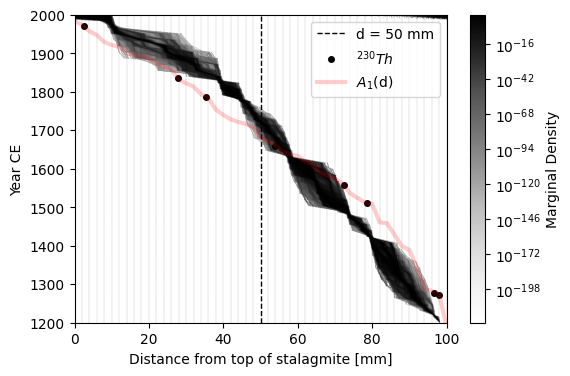

19343

In [ ]:
from matplotlib import colors

ns = len(samples[0, :, 0])
age = np.hstack([
    np.ones((ns, 1)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(samples[chain, :, :], axis=1)
])

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["H"] + dz, dz)
Z = z.size

t_edges = [1200, 2000]

K = int(len(samples[0, :, 0])/block_size)
C = np.full((Z, t_edges[-1] - t_edges[0]), np.nan)
for i in range(0, Z):
    hists = []
    ages = np.array([np.interp(z[i], data["cs"], age[j, :]) for j in range(ns)])
    print(np.ceil(np.max(ages)))
    bins = np.arange(np.floor(np.min(ages)), np.ceil(np.max(ages)) + 1, dtype = int)
    if bins.size < 2:
        bins = np.array([np.floor(np.min(ages)), np.floor(np.min(ages)) + 1])
    
    bin_indices = np.digitize(ages, bins) - 1
    num_bins = len(bins) - 1

    for b in range(num_bins):
        hists.append(np.sum(weights[chain, bin_indices == b]))

    full_hist = np.array(hists / (np.sum(weights[chain])))

    block_hists = np.zeros((K, num_bins))
    for k in range(K):
        start, end = k * block_size, (k + 1) * block_size
        # Slice the block's indices and weights
        b_idx = bin_indices[start:end]
        b_w = weights[chain, start:end]
        
        # Sum weights in this block
        for b in range(num_bins):
            block_hists[k, b] = np.sum(b_w[b_idx == b])

    loo_results = full_hist - block_hists
    norm_loo_results  = loo_results / (np.sum(weights[chain]) - np.array([np.sum(weights[chain, k*block_size:(k+1)*block_size]) for k in range(K)])[:, None])
    jackknife_est = K * full_hist - (K - 1) * np.mean(norm_loo_results, axis=0)
    C[i, bins[:-1]-t_edges[0]] = jackknife_est
    print(i/Z)


In [1]:
print(C)

NameError: name 'C' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = data_color, linewidth=3, alpha = 0.2, label = data_name + "(d)")
im = ax.imshow(
    C,
    extent=[z[0] + 1, z[-1], t_edges[0], t_edges[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

gc.collect()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = data_color, linewidth=3, alpha = 0.2, label = data_name + "(d)")
im = ax.imshow(
    C,
    extent=[z[0], z[-1], t_edges[0], t_edges[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

gc.collect()

In [ ]:
from matplotlib import colors

ns = len(samples[0, :, 0])
age = np.hstack([
    np.ones((ns, 1)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(samples[chain, :, :], axis=1)
])

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["H"] + dz, dz)
Z = z.size

t_edges = [1200, 2000]

K = int(len(samples[0, :, 0])/block_size)
C = np.full((Z, t_edges[-1] - t_edges[0]), np.nan)
var_est = []
for i in range(1, Z):
    hists = []
    ages = np.array([np.interp(z[i], data["cs"], age[j, :]) for j in range(ns)])
    print(np.ceil(np.max(ages)))
    bins = np.arange(np.floor(np.min(ages)), np.ceil(np.max(ages)) + 1, dtype = int)
    if bins.size < 2:
        bins = np.array(np.floor(np.min(ages)), np.floor(np.min(ages)) + 1)
    
    bin_indices = np.digitize(ages, bins) - 1
    num_bins = len(bins) - 1

    for b in range(num_bins):
        hists.append(np.sum(weights[chain, bin_indices == b]))

    full_hist = np.array(hists / (np.sum(weights[chain])))

    block_hists = np.zeros((K, num_bins))
    block_weights_sum = np.zeros((K))
    for k in range(K):
        start, end = k * block_size, (k + 1) * block_size
        # Slice the block's indices and weights
        b_idx = bin_indices[start:end]
        b_w = weights[chain, start:end]
        block_weights_sum[k] = np.sum(b_w)
        
        # Sum weights in this block
        for b in range(num_bins):
            block_hists[k, b] = np.sum(b_w[b_idx == b])

    est = np.sum(block_weights_sum*block_hists, axis = 0)/np.sum(block_weights_sum)
    meff = np.sum(block_weights_sum)**2 / np.sum(block_weights_sum**2)
    var_est.append(meff * np.sum(block_weights_sum * (block_hists - full_hist)**2, axis = 0) / ((meff - 1) *np.sum(block_weights_sum)))
    C[i, bins[:-1]-t_edges[0]] = est
    print(i/Z)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = data_color, linewidth=3, alpha = 0.2, label = data_name + "(d)")
im = ax.imshow(
    C,
    extent=[z[0], z[-1], t_edges[0], t_edges[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

In [ ]:
# from matplotlib import colors

# chain = 4
# X = short_samples[chain].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'purple', linewidth=3, alpha = 0.2, label = r"$A_1(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/samples_no_mean_{chain}.jpg")
# plt.show()

In [ ]:
# print(np.shape(true_age[:, None] - age))
# print(np.shape(age))
# print(np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0)))
# best_sol = age[:, np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0))]
# print(best_sol)
# print(np.linalg.norm(true_age[:, None] - age, axis = 0)[np.argmin(np.linalg.norm(true_age[:, None] - age, axis = 0))])

In [ ]:
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(data["cs"], best_sol, color = "green", linewidth = 3, alpha = 0.5, label = "best solution")
# ax.plot(data["cs"], true_age, color = "black", linewidth = 3, alpha = 0.5, label = "true solution")
# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.legend()
# plt.tight_layout()
# plt.savefig(f"{output_dir}/best_sol.jpg")
# plt.show()


In [ ]:
# plt.figure()
# plt.plot(data["cs"], best_sol - true_age)
# plt.xlabel("d [mm]")
# plt.ylabel(r"$\Delta A(d)$ [yr]")
# plt.show()

In [ ]:
# del model_ages
# gc.collect()